# Étude du Mouvement de Tumbling Rigide par PINN (Orbite de Jeffery)
Ce projet implémente une résolution par Réseaux de Neurones Informés par la Physique pour modéliser la rotation d'une particule ellipsoïdale rigide dans un fluide cisaillé. Il s'agit du cas limite où la viscosité interne est infinie ou la membrane immobile.

## 1. Modèle Physique : L'Équation de Jeffery
Dans le régime rigide, la dynamique est simplifiée car seule l'orientation $\theta(t)$ évolue. L'équation différentielle (EDO) est :$$\frac{d\theta}{dt} = \dot{\gamma} [A + B \cos(2\theta)]$$Paramètres de Forme$A = -0.5$ : Traduit la rotation pure due à la vorticité.$B = \frac{1}{2} \frac{r_p^2 - 1}{r_p^2 + 1}$ : Traduit l'influence de l'allongement de la particule (avec $r_p = a_1/a_2$).

## 2. Solution Analytique "Déroulée" (Unwrapped)
Pour entraîner le PINN efficacement, nous utilisons une solution exacte continue afin d'éviter les discontinuités de la fonction $arctan$.$$\theta_{exact}(t) = -\arctan\left( \frac{a_2}{a_1} \tan\left( \frac{2\pi t}{\tau} \right) \right) - \pi \cdot \text{floor}\left( \frac{t}{\tau/2} + 0.5 \right)$$Où $\tau$ est la période de Jeffery : $\tau = \frac{2\pi}{\dot{\gamma}} (r_p + \frac{1}{r_p})$.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
def tetha(a, b, t, gamma_dot=1.0):
    # Paramètres physiques selon Abkarian (Section 1.3.3)
    A = -0.5  # Vorticité (négatif pour rotation horaire) [cite: 901]
    B = 0.5 * (a**2 - b**2) / (a**2 + b**2) # Forme [cite: 902]
    rp=b/a
    
    # Période de Jeffery (tau) [cite: 800]
    tau = (2 * np.pi / gamma_dot) * (rp + 1/rp)
    
    # Coefficient effectif
    coeff = np.sqrt((A + B) / (A - B))
    
    # Calcul de l'angle périodique de base (entre -pi/2 et pi/2)
    # On utilise t/tau pour la progression temporelle
    theta_base = - np.arctan(coeff * np.tan(np.pi * t / (tau/2)))
    
    # Déroulement manuel pour une courbe continue
    # floor(t / (tau/2)) compte le nombre de demi-périodes passées
    n_half_turns = np.floor(t / (tau / 2) + 0.5)
    y = theta_base - np.pi * n_half_turns
    
    return  y

class FCN(nn.Module):
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )
        self.fch = nn.Sequential(*[
                        nn.Sequential(
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
        # Initialisation spécifique des poids (Xavier/Glorot) 
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # Xavier normal est optimal pour les activations Tanh
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

19.111355309337906
torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([10, 1]) torch.Size([10, 1])
tensor([[-0.0000],
        [-0.0962],
        [-0.2038],
        [-0.3395],
        [-0.5357],
        [-0.8611],
        [-1.4124],
        [-2.0491],
        [-2.4738],
        [-2.7195]])


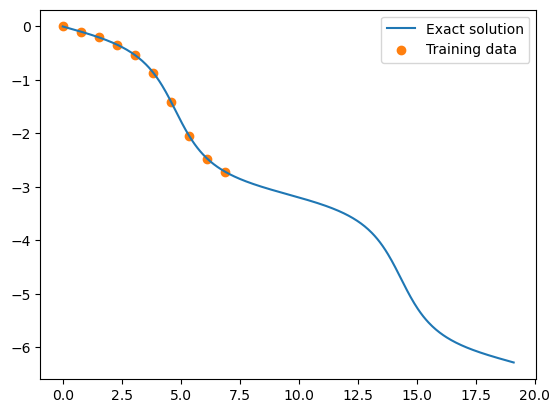

In [3]:
# condition initiale 
a ,b = 4,1.5
gamma_dot = 1.0
rp = b / a
# Période exacte de Jeffery / KS rigide
period = (2 * np.pi / gamma_dot) * (rp + 1/rp) 
print(period)

# Utilisez au moins une période complète pour l'entraînement
t = torch.linspace(0, period, 500).view(-1,1)
y = tetha(a, b, t).view(-1,1)
print(t.shape, y.shape)
# simulation 
t_data = t[0:200:20]
y_data = y[0:200:20]
print(t_data.shape, y_data.shape)
print(y_data)

plt.figure()
plt.plot(t, y, label="Exact solution")
plt.scatter(t_data, y_data, color="tab:orange", label="Training data")
plt.legend()
plt.show()

In [4]:
t_physics = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)

# 3. Boucle d'entraînement
model = FCN(1, 1, 32, 3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(6001): # Augmente le nombre d'époques, les PINNs sont lents
    optimizer.zero_grad()
    
    # 1. Prédiction globale
    x_pred = model(t_physics) 
    # 2. Conditions Initiales (Extraites du premier point de t_physics)
    # t_physics[0] vaut 0.0
    x_0_pred = x_pred[0]
    loss_x0 = (x_0_pred)**2
    # 3 Prédiction sur les points de mesure (les 10 points orange)
    y_data_pred = model(t_data) 
    loss_data = torch.mean((y_data_pred - y_data)**2)
    
    # 5. Total Loss avec pondération dynamique
    total_loss = 500 * loss_x0 + 300*loss_data
    
    total_loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Loss {total_loss.item():.6f}")

Epoch 0: Loss 732.684937
Epoch 1000: Loss 0.952740
Epoch 2000: Loss 0.011515
Epoch 3000: Loss 0.005878
Epoch 4000: Loss 0.003367
Epoch 5000: Loss 0.027292
Epoch 6000: Loss 0.001112


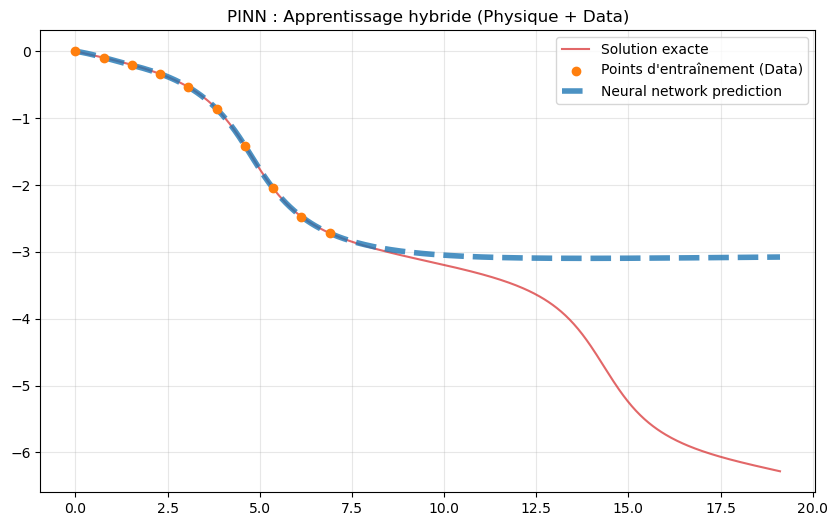

In [5]:
plt.figure(figsize=(10, 6))

# Solution exacte (Ligne bleue)
plt.plot(t_physics.detach(),tetha(a, b, t).detach(), label="Solution exacte", color="tab:red", alpha=0.7)

# Points d'entraînement (Points orange)
plt.scatter(t_data, y_data, color="tab:orange", label="Points d'entraînement (Data)", zorder=5)

# Prédiction PINN (Ligne rouge)
yh = model(t).detach()
y_pred = model(t_physics).detach()
plt.plot(t,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction",linestyle="--")

plt.title("PINN : Apprentissage hybride (Physique + Data)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
a, b = 4.0, 1.5
gamma_dot = 1.0
A = -0.5
B = 0.5 * (a**2 - b**2) / (a**2 + b**2)
# Période théorique pour couvrir une rotation complète 
period = (2 * np.pi) / (gamma_dot * np.sqrt(0.5**2 - B**2))

import torch
import numpy as np
import matplotlib.pyplot as plt

# Configuration de l'optimiseur L-BFGS
optimizer = torch.optim.LBFGS(
    model.parameters(), 
    lr=1, 
    max_iter=20, 
    history_size=10, 
    line_search_fn="strong_wolfe"
)

def closure():
    optimizer.zero_grad()
    
    # 1. Résidu Physique
    theta_pred_phys = model(t_physics)
    dtheta_dt = torch.autograd.grad(
        theta_pred_phys, t_physics, 
        torch.ones_like(theta_pred_phys), 
        create_graph=True
    )[0]
    
    # Équation : dθ/dt - γ * (A + B * cos(2θ)) = 0
    residu = dtheta_dt - gamma_dot * (A + B * torch.cos(2 * theta_pred_phys))
    loss_phys = torch.mean(residu**2)
    
    # 2. Condition Initiale (t=0, theta=0)
    t0 = torch.tensor([[0.0]], requires_grad=True)
    loss_ci = model(t0)**2
    
    # 3. Perte sur les données (Data)
    loss_data = torch.mean((model(t_data) - y_data)**2)
    
    # Somme pondérée
    total_loss = 300.0 * loss_phys + 500.0 * loss_ci + 100.0 * loss_data
    
    total_loss.backward()
    return total_loss

# Boucle d'optimisation
epochs = 500
for i in range(epochs):
    loss = optimizer.step(closure)
    if i % 50 == 0:
        print(f"Étape {i}: Loss totale = {loss.item():.6f}")

Étape 0: Loss totale = 2.349582
Étape 50: Loss totale = 1.042377
Étape 100: Loss totale = 0.407700
Étape 150: Loss totale = 0.017701
Étape 200: Loss totale = 0.004589
Étape 250: Loss totale = 0.004589
Étape 300: Loss totale = 0.004589
Étape 350: Loss totale = 0.004589
Étape 400: Loss totale = 0.004589
Étape 450: Loss totale = 0.004589


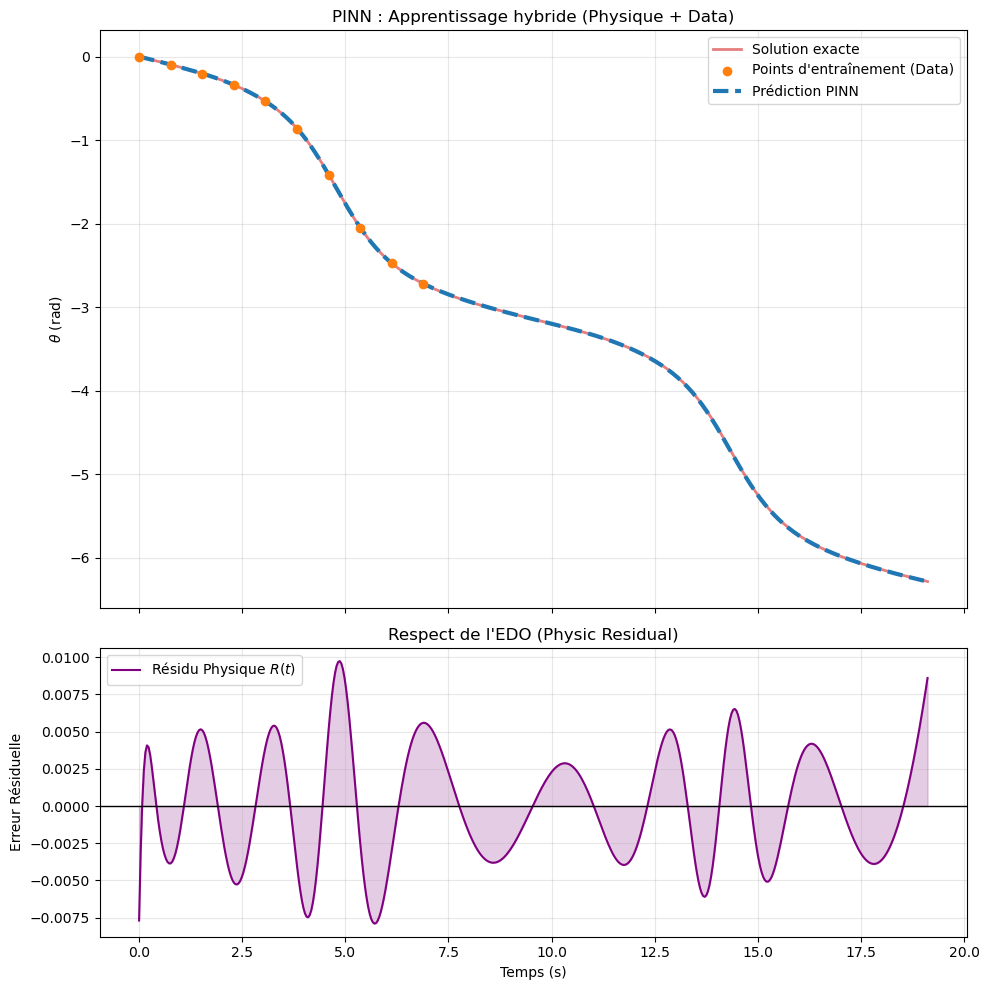

In [7]:
# 1. Génération des données de test
t_test = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)
y_pred_pinn = model(t_test)

# 2. Calcul du résidu physique final pour le plot
dtheta_dt_final = torch.autograd.grad(
    y_pred_pinn, t_test, torch.ones_like(y_pred_pinn), create_graph=True
)[0]
# On calcule le résidu ponctuel
res_final = (dtheta_dt_final - gamma_dot * (A + B * torch.cos(2 * y_pred_pinn))).detach().cpu().numpy()

# 3. Conversion pour NumPy (Sécurité pour matplotlib et fonction exacte)
t_plot = t_test.detach().cpu().numpy()
y_plot = y_pred_pinn.detach().cpu().numpy()
t_data_plot = t_data.detach().cpu().numpy()
y_data_plot = y_data.detach().cpu().numpy()

# --- Création du Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# Subplot 1 : Comparaison
# On passe t_plot (numpy) à la fonction tetha
ax1.plot(t_plot, tetha(a, b, t_plot), label="Solution exacte", color="tab:red", alpha=0.6, lw=2)
ax1.scatter(t_data_plot, y_data_plot, color="tab:orange", label="Points d'entraînement (Data)", zorder=5)
ax1.plot(t_plot, y_plot, color="tab:blue", linewidth=3, linestyle="--", label="Prédiction PINN")

ax1.set_ylabel(r"$\theta$ (rad)")
ax1.set_title("PINN : Apprentissage hybride (Physique + Data)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2 : Résidu Physique
ax2.fill_between(t_plot.flatten(), res_final.flatten(), color="purple", alpha=0.2)
ax2.plot(t_plot, res_final, color="purple", linewidth=1.5, label="Résidu Physique $R(t)$")

ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Erreur Résiduelle")
ax2.axhline(0, color='black', lw=1) # Ligne de zéro
ax2.set_title("Respect de l'EDO (Physic Residual)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
a, b = 4.0, 1.5
gamma_dot = 1.0
A = -0.5
B = 0.5 * (a**2 - b**2) / (a**2 + b**2)
# Période théorique pour couvrir une rotation complète 
period = (2 * np.pi) / (gamma_dot * np.sqrt(0.5**2 - B**2)) 

# Temps pour la physique (Couvre la période complète)
t_physics = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)
# Initialisation du modèle et de l'optimiseur
model = FCN(1, 1, 32, 3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20001):
    optimizer.zero_grad()
    
    # 1. Prédiction et Physique
    theta_pred = model(t_physics)
    dtheta_dt = torch.autograd.grad(
        theta_pred, t_physics, 
        torch.ones_like(theta_pred), 
        create_graph=True
    )[0]

    # Résidu de l'EDO
    physics_residu = dtheta_dt - gamma_dot * (A + B * torch.cos(2 * theta_pred))
    loss_physics = torch.mean(physics_residu**2)
    
    # 2. Condition Initiale
    loss_x0 = theta_pred[0]**2 
    
    # 3. Données expérimentales
    y_data_pred = model(t_data) 
    loss_data = torch.mean((y_data_pred - y_data)**2)
    
    # Pondération dynamique
    w_phys = 0.5 if epoch < 3000 else 20.0
    w_data = 100.0
    w_ci   = 500.0
    
    total_loss = w_phys * loss_physics + w_ci * loss_x0 + w_data * loss_data
    
    total_loss.backward()
    optimizer.step()

    if epoch % 2000 == 0:
        print(f"Epoch {epoch}: Loss {total_loss.item():.6f} (Phys: {loss_physics.item():.4f})")

Epoch 0: Loss 136.843109 (Phys: 0.0442)
Epoch 2000: Loss 0.012173 (Phys: 0.0077)
Epoch 4000: Loss 0.113041 (Phys: 0.0056)
Epoch 6000: Loss 0.109008 (Phys: 0.0051)
Epoch 8000: Loss 0.099144 (Phys: 0.0049)
Epoch 10000: Loss 0.096289 (Phys: 0.0048)
Epoch 12000: Loss 0.094718 (Phys: 0.0047)
Epoch 14000: Loss 0.093272 (Phys: 0.0047)
Epoch 16000: Loss 0.099422 (Phys: 0.0046)
Epoch 18000: Loss 0.094235 (Phys: 0.0045)
Epoch 20000: Loss 0.088776 (Phys: 0.0044)


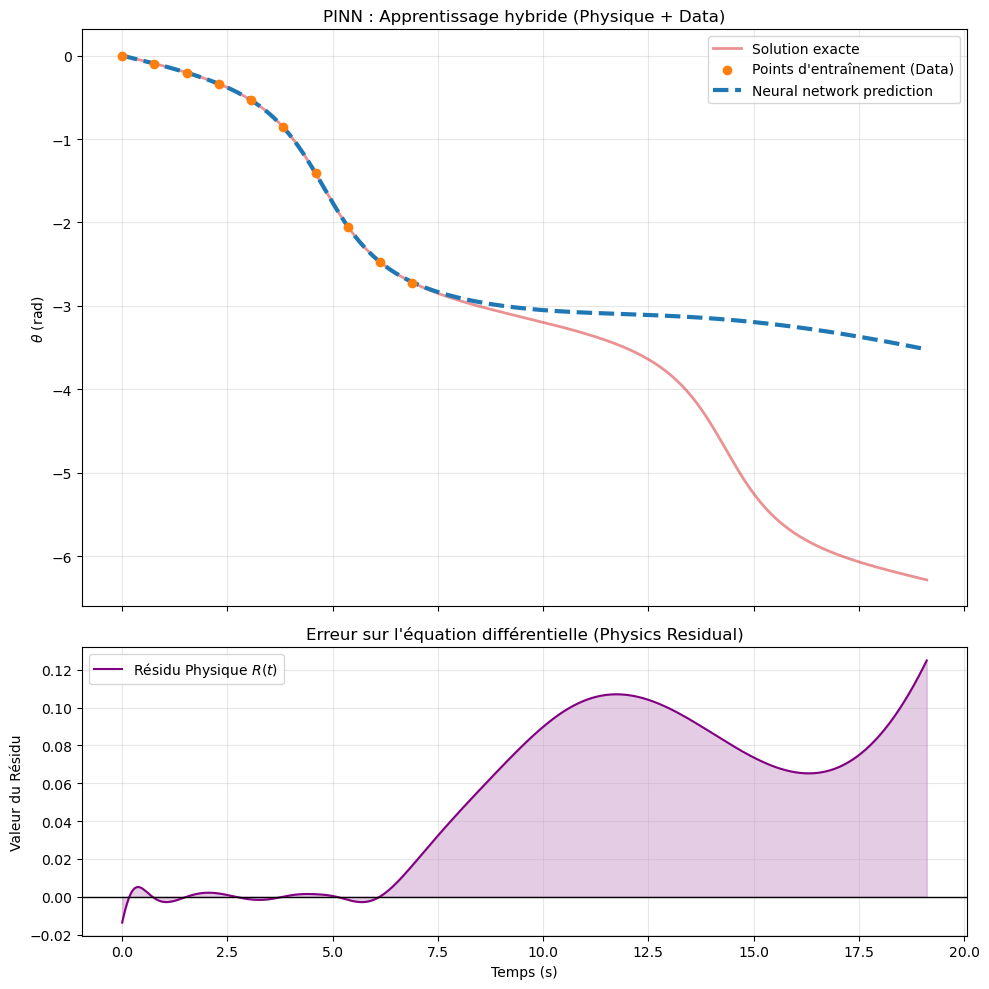

In [9]:
# 1. Préparation des données de test pour un tracé lisse
t_test = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)
y_pred_pinn = model(t_test)

# 2. Calcul du résidu physique ponctuel sur tout le domaine
dtheta_dt_test = torch.autograd.grad(
    y_pred_pinn, t_test, torch.ones_like(y_pred_pinn), create_graph=True
)[0]
# Calcul du résidu : R(t) = dθ/dt - [γ(A + B*cos(2θ))]
residu_final = (dtheta_dt_test - gamma_dot * (A + B * torch.cos(2 * y_pred_pinn))).detach().cpu().numpy()

# 3. Conversion sécurisée pour NumPy
t_plot = t_test.detach().cpu().numpy()
y_pinn_plot = y_pred_pinn.detach().cpu().numpy()
t_data_plot = t_data.detach().cpu().numpy()
y_data_plot = y_data.detach().cpu().numpy()

# --- Création de la Figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# --- SUBPLOT 1 : Solutions ---
# Solution exacte (Conversion numpy pour éviter l'erreur dans tetha)
ax1.plot(t_plot, tetha(a, b, t_plot), label="Solution exacte", color="tab:red", alpha=0.5, lw=2)

# Points d'entraînement
ax1.scatter(t_data_plot, y_data_plot, color="tab:orange", label="Points d'entraînement (Data)", zorder=5)

# Prédiction PINN
ax1.plot(t_plot, y_pinn_plot, color="tab:blue", linewidth=3, linestyle="--", label="Neural network prediction")

ax1.set_ylabel(r"$\theta$ (rad)")
ax1.set_title("PINN : Apprentissage hybride (Physique + Data)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- SUBPLOT 2 : Résidu Physique ---
# On affiche la valeur absolue ou brute pour voir les écarts à l'EDO
ax2.fill_between(t_plot.flatten(), residu_final.flatten(), color="purple", alpha=0.2)
ax2.plot(t_plot, residu_final, color="purple", linewidth=1.5, label="Résidu Physique $R(t)$")

ax2.axhline(0, color='black', lw=1, linestyle='-') # Ligne de référence zéro
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Valeur du Résidu")
ax2.set_title("Erreur sur l'équation différentielle (Physics Residual)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
def tetha(a, b, t, gamma_dot=1.0):
    # Paramètres physiques selon Abkarian (Section 1.3.3)
    A = -0.5  # Vorticité (négatif pour rotation horaire) [cite: 901]
    B = 0.5 * (a**2 - b**2) / (a**2 + b**2) # Forme [cite: 902]
    rp=b/a
    
    # Période de Jeffery (tau) [cite: 800]
    tau = (2 * np.pi / gamma_dot) * (rp + 1/rp)
    
    # Coefficient effectif
    coeff = np.sqrt((A + B) / (A - B))
    
    # Calcul de l'angle périodique de base (entre -pi/2 et pi/2)
    # On utilise t/tau pour la progression temporelle
    theta_base = - np.arctan(coeff * np.tan(np.pi * t / (tau/2)))
    y = theta_base
    
    return  y

class FCN(nn.Module):
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(
            nn.Linear(N_INPUT, N_HIDDEN),
            activation()
        )
        self.fch = nn.Sequential(*[
                        nn.Sequential(
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
        # Initialisation spécifique des poids (Xavier/Glorot) 
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # Xavier normal est optimal pour les activations Tanh
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

19.111355309337906
torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([10, 1]) torch.Size([10, 1])
tensor([[-0.0000],
        [-0.0962],
        [-0.2038],
        [-0.3395],
        [-0.5357],
        [-0.8611],
        [-1.4124],
        [ 1.0925],
        [ 0.6678],
        [ 0.4221]])


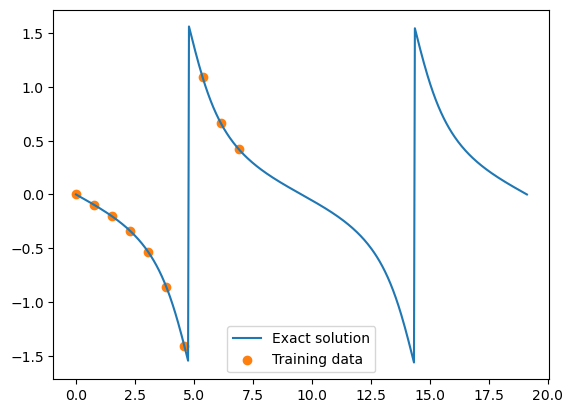

In [13]:
# condition initiale 
a ,b = 4,1.5
gamma_dot = 1.0
rp = b / a
# Période exacte de Jeffery / KS rigide
period =(2 * np.pi / gamma_dot) * (rp + 1/rp) 
print(period)

# Utilisez au moins une période complète pour l'entraînement
t = torch.linspace(0, period, 500).view(-1,1)
y = tetha(a, b, t).view(-1,1)
print(t.shape, y.shape)
# simulation 
t_data = t[0:200:20]
y_data = y[0:200:20]
print(t_data.shape, y_data.shape)
print(y_data)

plt.figure()
plt.plot(t, y, label="Exact solution")
plt.scatter(t_data, y_data, color="tab:orange", label="Training data")
plt.legend()
plt.show()

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
a, b = 4.0, 1.5
gamma_dot = 1.0
A = -0.5
B = 0.5 * (a**2 - b**2) / (a**2 + b**2)
# Période théorique pour couvrir une rotation complète 
period = (2 * np.pi) / (gamma_dot * np.sqrt(0.5**2 - B**2))

import torch
import numpy as np
import matplotlib.pyplot as plt

# Configuration de l'optimiseur L-BFGS
optimizer = torch.optim.LBFGS(
    model.parameters(), 
    lr=1, 
    max_iter=20, 
    history_size=10, 
    line_search_fn="strong_wolfe"
)

def closure():
    optimizer.zero_grad()
    
    # 1. Résidu Physique
    theta_pred_phys = model(t_physics)
    dtheta_dt = torch.autograd.grad(
        theta_pred_phys, t_physics, 
        torch.ones_like(theta_pred_phys), 
        create_graph=True
    )[0]
    
    # Équation : dθ/dt - γ * (A + B * cos(2θ)) = 0
    residu = dtheta_dt - gamma_dot * (A + B * torch.cos(2 * theta_pred_phys))
    loss_phys = torch.mean(residu**2)
    
    # 2. Condition Initiale (t=0, theta=0)
    t0 = torch.tensor([[0.0]], requires_grad=True)
    loss_ci = model(t0)**2
    
    # 3. Perte sur les données (Data)
    loss_data = torch.mean((model(t_data) - y_data)**2)
    
    # Somme pondérée
    total_loss = 300.0 * loss_phys + 500.0 * loss_ci + 100.0 * loss_data
    
    total_loss.backward()
    return total_loss

# Boucle d'optimisation
epochs = 500
for i in range(epochs):
    loss = optimizer.step(closure)
    if i % 50 == 0:
        print(f"Étape {i}: Loss totale = {loss.item():.6f}")

Étape 0: Loss totale = 295.513733
Étape 50: Loss totale = 130.425308
Étape 100: Loss totale = 130.403824
Étape 150: Loss totale = 130.403824
Étape 200: Loss totale = 130.403824
Étape 250: Loss totale = 130.403824
Étape 300: Loss totale = 130.403824
Étape 350: Loss totale = 130.403824
Étape 400: Loss totale = 130.403824
Étape 450: Loss totale = 130.403824


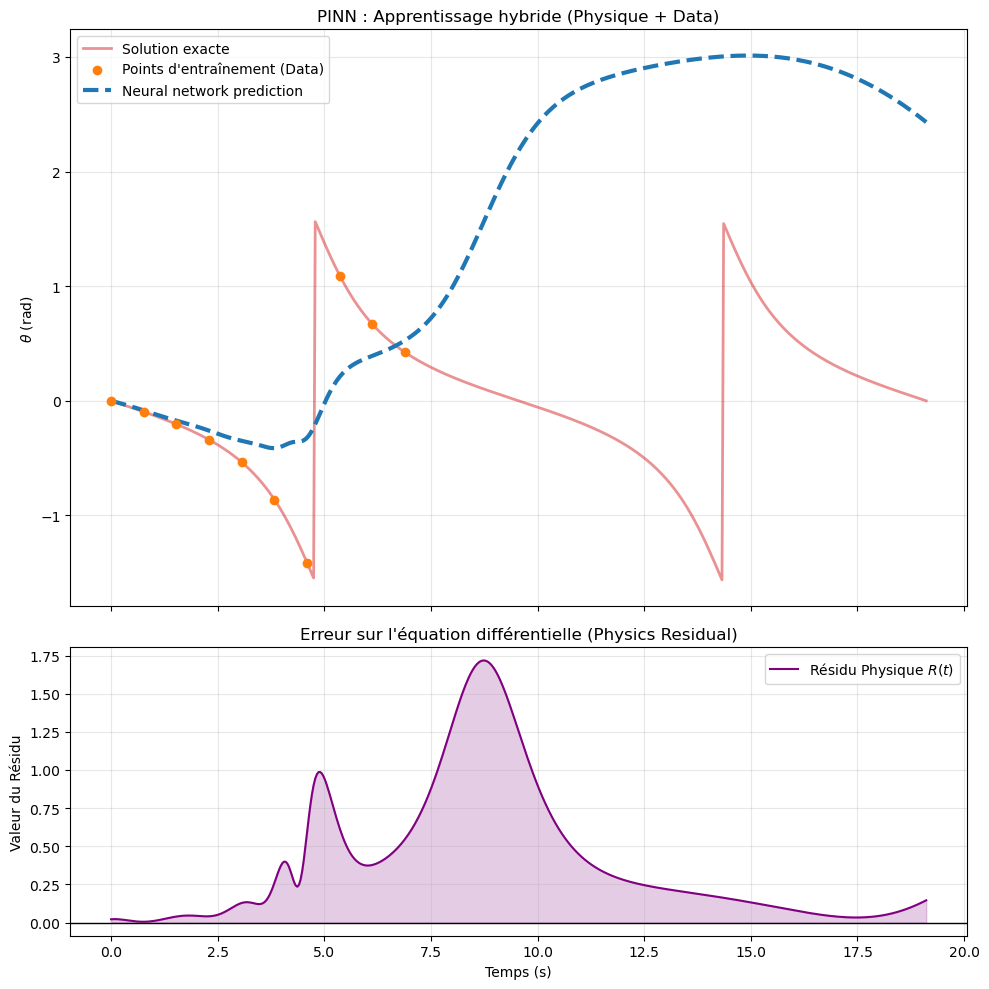

In [15]:
# 1. Préparation des données de test pour un tracé lisse
t_test = torch.linspace(0, period, 500).view(-1, 1).requires_grad_(True)
y_pred_pinn = model(t_test)

# 2. Calcul du résidu physique ponctuel sur tout le domaine
dtheta_dt_test = torch.autograd.grad(
    y_pred_pinn, t_test, torch.ones_like(y_pred_pinn), create_graph=True
)[0]
# Calcul du résidu : R(t) = dθ/dt - [γ(A + B*cos(2θ))]
residu_final = (dtheta_dt_test - gamma_dot * (A + B * torch.cos(2 * y_pred_pinn))).detach().cpu().numpy()

# 3. Conversion sécurisée pour NumPy
t_plot = t_test.detach().cpu().numpy()
y_pinn_plot = y_pred_pinn.detach().cpu().numpy()
t_data_plot = t_data.detach().cpu().numpy()
y_data_plot = y_data.detach().cpu().numpy()

# --- Création de la Figure ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [2, 1]})

# --- SUBPLOT 1 : Solutions ---
# Solution exacte (Conversion numpy pour éviter l'erreur dans tetha)
ax1.plot(t_plot, tetha(a, b, t_plot), label="Solution exacte", color="tab:red", alpha=0.5, lw=2)

# Points d'entraînement
ax1.scatter(t_data_plot, y_data_plot, color="tab:orange", label="Points d'entraînement (Data)", zorder=5)

# Prédiction PINN
ax1.plot(t_plot, y_pinn_plot, color="tab:blue", linewidth=3, linestyle="--", label="Neural network prediction")

ax1.set_ylabel(r"$\theta$ (rad)")
ax1.set_title("PINN : Apprentissage hybride (Physique + Data)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- SUBPLOT 2 : Résidu Physique ---
# On affiche la valeur absolue ou brute pour voir les écarts à l'EDO
ax2.fill_between(t_plot.flatten(), residu_final.flatten(), color="purple", alpha=0.2)
ax2.plot(t_plot, residu_final, color="purple", linewidth=1.5, label="Résidu Physique $R(t)$")

ax2.axhline(0, color='black', lw=1, linestyle='-') # Ligne de référence zéro
ax2.set_xlabel("Temps (s)")
ax2.set_ylabel("Valeur du Résidu")
ax2.set_title("Erreur sur l'équation différentielle (Physics Residual)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()